## Load data

This dataset was generated from [LSA64](https://facundoq.github.io/datasets/lsa64/), which contains videos of isolated sign language. It is composed of 64 signs in Argentine Sign Language (LSA) repeated multiple times by different signers. For this dataset, the poses of the signers were extracted using [MediaPipe Holistic](https://ai.google.dev/edge/mediapipe/solutions/vision/holistic_landmarker?hl=es-419).

The data is split into train and test folders:

The **train** folder contains the following files:

- `labels.csv`: a CSV file containing the labels of the training data. The file has the following columns:
  - `ID`: the ID of the data sample.
  - `Label`: the label of the data sample.

- `poses/`: a folder containing the pose data of the training samples. The pose data is stored as NumPy arrays in the following format:
  - Shape: `(num_frames, num_keypoints, 3)`
  - `num_frames`: the number of frames in the pose data.
  - `num_keypoints`: the number of keypoints in the pose data.
  - `3`: the x, y, and confidence values of each keypoint.

The **test** folder contains a poses folder following the same structure as the train folder. The labels of these files are kept private and will be used for evaluation.

In [ ]:
import os
import pandas as pd
import numpy as np


input_path = "/kaggle/input/cacic-escuela-de-informatica-deep-learning"
train_path = f"{input_path}/data/train"

# Read train labels
train_labels_df = pd.read_csv(os.path.join(train_path, "labels.csv"))
train_labels = train_labels_df["Label"].values
train_labels_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/cacic-escuela-de-informatica-deep-learning/data/train/labels.csv'

In [ ]:
import os
import pandas as pd
import numpy as np


input_path = "./example_data"
train_path = f"{input_path}/data/train"

# Read train labels
train_labels_df = pd.read_csv(os.path.join(train_path, "labels.csv"))
train_labels = train_labels_df["Label"].values
train_labels_df.head()

,ID,Label
0,0,sign_class_A
1,1,sign_class_B
2,2,sign_class_A
3,3,sign_class_C
4,4,sign_class_B


### Crear la estructura de carpetas de ejemplo

In [ ]:
import os

# Define the base input path where the data will be created
example_input_path = "./example_data"

# Define paths for train and test directories
example_train_path = os.path.join(example_input_path, "data", "train")
example_test_path = os.path.join(example_input_path, "data", "test")

# Create directories if they don't exist
os.makedirs(os.path.join(example_train_path, "poses"), exist_ok=True)
os.makedirs(os.path.join(example_test_path, "poses"), exist_ok=True)

print(f"Directorios creados en: {example_input_path}")

Directorios creados en: ./example_data


### Crear un archivo `labels.csv` de ejemplo

In [ ]:
import pandas as pd
import numpy as np

# Sample labels for training data (Ensuring at least 2 samples per class for stratification)
sample_labels_data = {
    "ID": [0, 1, 2, 3, 4, 5, 6, 7],
    "Label": ["sign_class_A", "sign_class_B", "sign_class_A", "sign_class_C", "sign_class_B", "sign_class_A", "sign_class_C", "sign_class_B"]
}
example_labels_df = pd.DataFrame(sample_labels_data)

# Save to CSV
labels_csv_path = os.path.join(example_train_path, "labels.csv")
example_labels_df.to_csv(labels_csv_path, index=False)

print(f"Archivo labels.csv creado en: {labels_csv_path}")
display(example_labels_df.head())

Archivo labels.csv creado en: ./example_data/data/train/labels.csv


,ID,Label
0,0,sign_class_A
1,1,sign_class_B
2,2,sign_class_A
3,3,sign_class_C
4,4,sign_class_B


### Crear archivos `.npy` de ejemplo para poses

In [ ]:
import numpy as np

# Parameters for example pose data
num_train_samples = 8 # Updated to match the new number of labels
num_test_samples = 3
num_keypoints = 75 # Example value, matches the model's expected input
max_frames_example = 50 # Example max frames, will vary in real data

# Create example .npy files for training poses
for i in range(num_train_samples):
    # Simulate varying number of frames for each pose
    current_frames = np.random.randint(10, max_frames_example + 1)
    # Each keypoint has (x, y, confidence)
    pose_data = np.random.rand(current_frames, num_keypoints, 3).astype(np.float32)
    np.save(os.path.join(example_train_path, "poses", f"{i}.npy"), pose_data)
print(f"Creadas {num_train_samples} archivos .npy de entrenamiento.")

# Create example .npy files for testing poses
# IDs for test samples should not overlap with train if they are separate datasets
# For simplicity, let's use IDs starting from a different number or continue the sequence
for i in range(num_test_samples):
    current_frames = np.random.randint(10, max_frames_example + 1)
    pose_data = np.random.rand(current_frames, num_keypoints, 3).astype(np.float32)
    # Test IDs can start after train IDs or have their own sequence
    np.save(os.path.join(example_test_path, "poses", f"{i}.npy"), pose_data)
print(f"Creadas {num_test_samples} archivos .npy de prueba.")

print("\nAhora puedes cambiar la variable `input_path` en tu notebook a: ")
print(f"input_path = '{example_input_path}'")
print("y el resto del código debería funcionar con esta estructura de ejemplo.")

Creadas 8 archivos .npy de entrenamiento.
Creadas 3 archivos .npy de prueba.

Ahora puedes cambiar la variable `input_path` en tu notebook a: 
input_path = './example_data'
y el resto del código debería funcionar con esta estructura de ejemplo.


El `input_path` que se establece en `/kaggle/input/cacic-escuela-de-informatica-deep-learning` debe apuntar a la carpeta raíz que contenga tu conjunto de datos. Dentro de esta carpeta raíz, la estructura debe ser la siguiente:

```
input_path/
├── data/
│   ├── train/
│   │   ├── labels.csv
│   │   └── poses/
│   │       ├── 0.npy
│   │       ├── 1.npy
│   │       ├── ...
│   │       └── N.npy
│   └── test/
│       └── poses/
│           ├── M.npy
│           ├── M+1.npy
│           └── ...
│           └── K.npy
```

### Descripción de los archivos:

1.  **`labels.csv`** (dentro de `input_path/data/train/`):
    *   Este archivo CSV debe contener las etiquetas para los datos de entrenamiento.
    *   Debe tener al menos dos columnas:
        *   `ID`: Un identificador numérico único para cada muestra de datos. Estos IDs corresponden a los nombres de los archivos `.npy` (sin la extensión).
        *   `Label`: La etiqueta de clase para cada muestra.

    *   **Ejemplo de `labels.csv`:**

        ```csv
        ID,Label
        0,sign_class_1
        1,sign_class_2
        2,sign_class_1
        ...
        ```

2.  **Archivos `.npy`** (dentro de `input_path/data/train/poses/` y `input_path/data/test/poses/`):
    *   Cada archivo `.npy` contiene los datos de pose de un video.
    *   El nombre del archivo (ej. `0.npy`, `1.npy`) debe corresponder al `ID` en `labels.csv` para el conjunto de entrenamiento.
    *   Los datos dentro de cada archivo `.npy` deben ser un array NumPy con la siguiente forma:
        *   `shape: (num_frames, num_keypoints, 3)`
        *   `num_frames`: El número de fotogramas en el video de la pose.
        *   `num_keypoints`: El número de puntos clave detectados en cada fotograma.
        *   `3`: Representa las coordenadas `(x, y)` y un valor de confianza para cada punto clave (`[x, y, confidence]`).

### Para visualizar y entrenar el modelo:

1.  **Asegúrate de que la ruta sea correcta:** La variable `input_path` debe ser la ruta absoluta o relativa a la carpeta que contiene `data/`. Si estás trabajando en Colab y los datos están montados desde Google Drive, por ejemplo, `input_path` debería apuntar a la carpeta raíz de tus datos en Drive.
2.  **Carga de datos:** Una vez que la estructura de carpetas y archivos sea la correcta, el código existente debería poder cargar `labels.csv` y los archivos `.npy` sin errores.
3.  **Entrenamiento:** Después de cargar y preprocesar los datos (padding de poses), el modelo se entrenará con `x_train_array` y `y_train_array` que se construyen a partir de tus datos.

In [ ]:
# Load train poses
train_poses = []
for id in train_labels_df["ID"]:
    pose = np.load(f"{train_path}/poses/{id}.npy")
    train_poses.append(pose)

print(
    f"Dataset contains {len(train_poses)} samples for training belonging to {len(set(train_labels))} classes."
)

Dataset contains 8 samples for training belonging to 3 classes.


### Sample visualization

In [ ]:
%matplotlib notebook

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation


def animate(
    pose,
    h: int = 4,
    w: int = 4,
    size=10,
):
    def get_update(scatter):
        def update(frame):
            # Reshape keypoints to have each pair (x, y) in a row
            x = pose[frame, :, 0]
            y = pose[frame, :, 1]
            scatter.set_offsets(np.array((x, y)).T)
            return (scatter,)

        return update

    fig, ax = plt.subplots(figsize=(h, w))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.invert_yaxis()  # Invert y-axis so origin is at top-left
    scatter = ax.scatter([], [], s=size)
    return FuncAnimation(
        fig, get_update(scatter), frames=len(pose), interval=50, blit=True
    )

In [ ]:
from IPython.display import HTML
import random


rand_index = random.randint(0, len(train_poses))
pose = train_poses[rand_index]
anim = animate(pose)
HTML(anim.to_jshtml())

<IPython.core.display.Javascript object>

## Data processing

### Normalize video lenghts

In [ ]:
def pad_poses(poses, max_frames):
    return [np.pad(p, ((0, max_frames - p.shape[0]), (0, 0), (0, 0))) for p in poses]


# check min and max frame amount of keypoints
min_frames = min(p.shape[0] for p in train_poses)
# an extra margin of 10 frames is added to the max_frames in case poses from test set have more frames
max_frames = max(p.shape[0] for p in train_poses) + 10
print(f"Min frames: {min_frames}, Max frames: {max_frames}")

# add padding to the end of each pose to make them all the same length
padded_poses = pad_poses(poses=train_poses, max_frames=max_frames)

Min frames: 10, Max frames: 58


In [ ]:
anim = animate(padded_poses[rand_index])
HTML(anim.to_jshtml())

<IPython.core.display.Javascript object>

## Split data

We will generate a "test" set from our data available.

In [ ]:
from sklearn.model_selection import train_test_split

y_train, y_test, x_train, x_test = train_test_split(
    train_labels,
    padded_poses,
    stratify=train_labels,
    test_size=0.4, # Increased test_size to ensure enough samples for stratification
    random_state=42,
    shuffle=True,
)
print(len(x_train), len(x_test))

4 4


In [ ]:
x_train_array = np.array(x_train)
y_train_array = np.array(y_train)

# Map labels to integers starting from 0, if necessary, for sparse_categorical_crossentropy
# (Assuming labels are strings like 'sign_class_A', 'sign_class_B', etc.)
# Create a mapping from string labels to integer IDs if y_train is not already integer-encoded
if y_train_array.dtype == object: # Check if labels are non-numeric
    unique_labels = sorted(list(set(y_train_array)))
    label_to_int = {label: i for i, label in enumerate(unique_labels)}
    y_train_array = np.array([label_to_int[label] for label in y_train_array])


y_train_array = y_train_array.reshape(-1, 1)

print(f"Training set shape: {x_train_array.shape}")
print(f"Training labels shape: {y_train_array.shape}")

Training set shape: (4, 58, 75, 3)
Training labels shape: (4, 1)


## Model

### Definition

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    TimeDistributed,
    Flatten,
    Dropout,
    BatchNormalization,
    Conv1D,
    MaxPooling1D,
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2


input_shape = (max_frames, 75, 3)
inputs = Input(shape=input_shape)

# TimeDistributed layer applies the same operation to each frame along the time axis (expected input shape: batch, time, features)
x = TimeDistributed(Flatten())(inputs)

# A dense layer is applied to each frame, intended as encoder of each pose frame
x = TimeDistributed(Dense(128, activation="relu", kernel_regularizer=l2(1e-4)))(x)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(Dropout(0.3))(x)

# A 1D convolutional layer is applied through the time axis to capture temporal patterns, looking at a window of 3 frames
x = Conv1D(128, kernel_size=3, activation="relu")(x)
x = MaxPooling1D(pool_size=2)(x)

# LSTM layers are used to capture temporal dependencies
x = LSTM(256, return_sequences=True)(x)
x = Dropout(0.5)(x)
x = LSTM(256, return_sequences=False)(x)
x = Dropout(0.5)(x)

# Output layer with as many units as classes and softmax activation for multi-class classification
outputs = Dense(len(set(train_labels)), activation="softmax")(x)

# Build model
model = Model(inputs=inputs, outputs=outputs)

In [ ]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 58, 75, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 58, 225)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 58, 128)        │        28,928 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 58, 128)        │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 58, 128)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 56, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 28, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 999,043 (3.81 MB)

 Trainable params: 998,787 (3.81 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
model.predict(x_train_array[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([[0.33442113, 0.32551646, 0.3400624 ]], dtype=float32)

### Training

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping


# Early Stopping callback to stop training when the validation loss does not improve
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

# Train model
history = model.fit(
    x_train_array,
    y_train_array,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step - accuracy: 0.0000e+00 - loss: 1.1704 - val_accuracy: 0.0000e+00 - val_loss: 1.1459
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 960ms/step - accuracy: 0.3333 - loss: 1.1048 - val_accuracy: 0.0000e+00 - val_loss: 1.1958
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 1.0000 - loss: 1.0040 - val_accuracy: 0.0000e+00 - val_loss: 1.2626
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.6667 - loss: 1.0154 - val_accuracy: 0.0000e+00 - val_loss: 1.3443
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 1.0000 - loss: 0.9700 - val_accuracy: 0.0000e+00 - val_loss: 1.4409
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 1.0000 - loss: 0.9515 - val_accuracy: 0.0000e+00 - val_loss: 1.5459
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 1.0000 - loss: 0.8690 - val_accuracy: 0.0000e+00 - val_loss: 1.6595
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 1.0000 - loss: 0.8480 - v

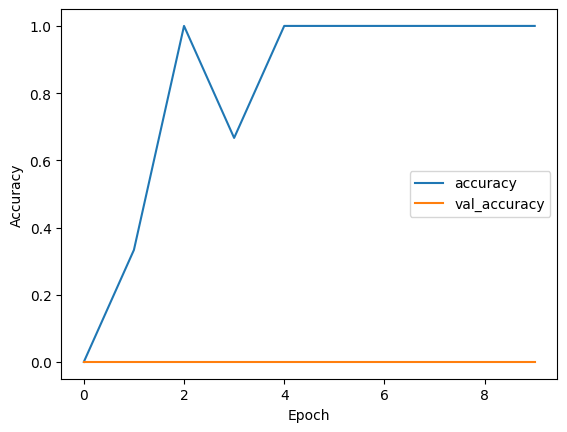

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt

# Close all previously opened figures to clear any lingering animation states
plt.close('all')

# plot history
plt.figure()
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Run model over test data

After training the model, we have to run it over the test set and submit the results.

In [ ]:
# load test data
test_path = f"{input_path}/data/test"
test_poses = []
ids = sorted([int(id.split(".")[0]) for id in os.listdir(f"{test_path}/poses")])
for id in ids:
    pose = np.load(f"{test_path}/poses/{id}.npy")
    test_poses.append(pose)
print(f"Dataset contains {len(test_poses)} samples for testing.")

Dataset contains 3 samples for testing.


In [ ]:
# get results for test data
padded_test_poses = [
    np.pad(p, ((0, max_frames - p.shape[0]), (0, 0), (0, 0))) for p in test_poses
]
x_test_array = np.array(padded_test_poses)
y_pred = model.predict(x_test_array)
y_pred_array = np.argmax(y_pred, axis=1) + 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [ ]:
len(y_pred_array)

3

In [ ]:
# Store predictions in a CSV file to submit to the competition
pd.DataFrame({"ID": ids, "Label": y_pred_array}).to_csv("submission.csv", index=False)